# regressão com regularização (ridge/lasso)

objetivo deste notebook:
- treinar modelos para prever preço de revenda de carros
- comparar baseline linear, ridge (L2) e lasso (L1)
- tratar categóricas com one-hot e analisar overfitting vs underfitting

## roteiro

1. carregamento de treino com target  
2. parsing + preparo de features  
3. pipeline com one-hot + imputação + escala  
4. treino e comparação (linear/ridge/lasso)  
5. multicolinearidade e regularização  
6. leitura do melhor modelo


In [42]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display

from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

PASTEL_CYCLE = [
    "#A8DADC",  # azul pastel
    "#FFCAD4",  # rosa pastel
    "#CDEAC0",  # verde pastel
    "#C7CEEA",  # lilas pastel
    "#FFD6A5",  # pessego pastel
    "#BDE0FE",  # azul claro
    "#E4C1F9",  # roxo claro
    "#F1C0E8",  # rosa lavanda
]
PASTEL_POS = "#F6BD60"
PASTEL_NEG = "#84A59D"

sns.set_theme(style="whitegrid")
sns.set_palette(PASTEL_CYCLE)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PASTEL_CYCLE)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [43]:
DATA_DIR = Path("../data")
target_candidates = ["Price", "price", "Selling_Price", "selling_price", "Sale_Price", "target"]

preferred_train_files = ["train-data.csv", "train.csv", "used_cars_data.csv", "car_price.csv"]
all_csv = sorted(DATA_DIR.glob("*.csv"))

selected_train_file = None
for fname in preferred_train_files:
    fpath = DATA_DIR / fname
    if not fpath.exists():
        continue
    tmp = pd.read_csv(fpath, nrows=5)
    if any(tc in tmp.columns for tc in target_candidates):
        selected_train_file = fpath
        break

if selected_train_file is None:
    for fpath in all_csv:
        tmp = pd.read_csv(fpath, nrows=5)
        if any(tc in tmp.columns for tc in target_candidates):
            selected_train_file = fpath
            break

if selected_train_file is None:
    files_str = ", ".join([f.name for f in all_csv]) if all_csv else "nenhum csv"
    raise ValueError(
        "não encontrei arquivo de treino com target de preço. "
        f"arquivos disponíveis: {files_str}. "
        "adicione um csv de treino contendo coluna Price/Selling_Price para rodar este notebook."
    )

df_raw = pd.read_csv(selected_train_file).copy()
df_raw.columns = [c.strip() for c in df_raw.columns]
unnamed_cols = [c for c in df_raw.columns if c.lower().startswith("unnamed")]
if unnamed_cols:
    df_raw = df_raw.drop(columns=unnamed_cols)

target_col = next(tc for tc in target_candidates if tc in df_raw.columns)

print(f"arquivo de treino: {selected_train_file.name}")
print(f"shape: {df_raw.shape}")
print(f"target: {target_col}")

arquivo de treino: train-data.csv
shape: (6019, 13)
target: Price


## 2) parsing e preparo das features

aqui converto colunas em texto numérico para formato numérico e gero features úteis (`Age`, `Brand`).


In [44]:
import re

def parse_numeric_from_text(s):
    if pd.isna(s):
        return np.nan
    s = str(s).replace(",", ".")
    m = re.search(r"[-+]?\d*\.?\d+", s)
    return float(m.group()) if m else np.nan

def parse_mileage_value_unit(s):
    if pd.isna(s):
        return (np.nan, np.nan)
    s_low = str(s).strip().lower().replace(",", ".")
    val = parse_numeric_from_text(s_low)

    if "km/kg" in s_low:
        unit = "kmkg"
    elif "kmpl" in s_low:
        unit = "kmpl"
    else:
        unit = np.nan

    return (val, unit)

def parse_new_price_lakh(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    num = parse_numeric_from_text(s)
    if pd.isna(num):
        return np.nan
    s_low = s.lower()
    if "cr" in s_low:
        return num * 100.0
    if "lakh" in s_low:
        return num
    return num

df = df_raw.copy()

if "Mileage" in df.columns:
    mil = df["Mileage"].apply(parse_mileage_value_unit)
    df["Mileage_num"] = mil.str[0]
    df["Mileage_unit"] = mil.str[1]
    df["Mileage_is_kmkg"] = (df["Mileage_unit"] == "kmkg").astype("Int64")
if "Engine" in df.columns:
    df["Engine_num"] = df["Engine"].apply(parse_numeric_from_text)
if "Power" in df.columns:
    df["Power_num"] = df["Power"].apply(parse_numeric_from_text)
if "New_Price" in df.columns:
    df["New_Price_lakh"] = df["New_Price"].apply(parse_new_price_lakh)

ref_year = None
if "Year" in df.columns:
    year_non_null = df["Year"].dropna()
    if not year_non_null.empty:
        ref_year = int(year_non_null.max())
        df["Age"] = (ref_year - df["Year"]).clip(lower=0)
    else:
        df["Age"] = np.nan

if "Name" in df.columns:
    df["Brand"] = df["Name"].astype(str).str.split().str[0]
    df["Model_short"] = df["Name"].astype(str).str.split().str[:2].str.join(" ")

    min_freq = 20
    vc = df["Model_short"].value_counts(dropna=False)
    keep = vc[vc >= min_freq].index
    df["Model_short_capped"] = df["Model_short"].where(df["Model_short"].isin(keep), "Other")

if ref_year is not None:
    print(f"ano de referência usado para Age: {ref_year}")

display_cols = [
    c for c in [
        "Mileage_num",
        "Mileage_unit",
        "Mileage_is_kmkg",
        "Engine_num",
        "Power_num",
        "New_Price_lakh",
        "Age",
        "Brand",
        "Model_short_capped",
    ] if c in df.columns
]
display(df[display_cols].head())

ano de referência usado para Age: 2019


,Mileage_num,Mileage_unit,Mileage_is_kmkg,Engine_num,Power_num,New_Price_lakh,Age,Brand,Model_short_capped
0,26.6000,kmkg,1,998.0000,58.1600,NaN,9,Maruti,Maruti Wagon
1,19.6700,kmpl,0,"1,582.0000",126.2000,NaN,4,Hyundai,Hyundai Creta
2,18.2000,kmpl,0,"1,199.0000",88.7000,8.6100,8,Honda,Honda Jazz
3,20.7700,kmpl,0,"1,248.0000",88.7600,NaN,7,Maruti,Maruti Ertiga
4,15.2000,kmpl,0,"1,968.0000",140.8000,NaN,6,Audi,Audi A4


- aqui eu padronizei conversões numéricas de texto (`mileage`, `engine`, `power`, `new_price`) de forma mais robusta
- o parsing agora aceita vírgula decimal e extrai só a parte numérica, reduzindo erro de conversão
- em `Mileage`, separei valor e unidade (`Mileage_num`, `Mileage_unit`) e criei a flag `Mileage_is_kmkg` para o modelo diferenciar `kmpl` de `km/kg`
- `New_Price` foi convertida para a mesma escala (`lakh`), então os valores ficam comparáveis
- `Age` passou a usar ano de referência do próprio dataset (`2019`), evitando hardcode fixo no tempo e deixando o resultado reprodutível
- extraí `Brand` e criei `Model_short_capped` para reduzir cardinalidade e controlar explosão de dummies no one-hot
- quando não há valor válido, mantive `NaN`, deixando a imputação para o pipeline

implicações para modelagem
- esse bloco já prepara melhor o terreno para ridge/lasso (menos ruído e menos dimensionalidade desnecessária)
- `Model_short_capped` tende a ajudar estabilidade dos coeficientes
- `Mileage_unit`/`Mileage_is_kmkg` preservam informação importante que antes se perdia no parsing simples

In [45]:
candidate_base_features = [
    "Age",
    "Kilometers_Driven",
    "Mileage_num",
    "Mileage_is_kmkg",
    "Engine_num",
    "Power_num",
    "Seats",
    "Brand",
    "Location",
    "Fuel_Type",
    "Transmission",
    "Owner_Type",
]

feature_sets = {
    "sem_new_price": [c for c in candidate_base_features if c in df.columns],
}

if "New_Price_lakh" in df.columns:
    with_new_price = [c for c in candidate_base_features if c in df.columns] + ["New_Price_lakh"]
    feature_sets["com_new_price"] = list(dict.fromkeys(with_new_price))

df_model_base = df.copy()

# agrupa categorias raras para reduzir ruído no one-hot
rare_min_count = 20
for col in ["Brand", "Owner_Type", "Fuel_Type", "Location"]:
    if col in df_model_base.columns:
        vc = df_model_base[col].value_counts(dropna=False)
        keep = set(vc[vc >= rare_min_count].index)
        df_model_base[col] = df_model_base[col].where(
            df_model_base[col].isin(keep) | df_model_base[col].isna(),
            "Other",
        )

datasets = {}
for scenario_name, feature_cols in feature_sets.items():
    tmp = df_model_base[feature_cols + [target_col]].copy()
    tmp = tmp[tmp[target_col].notna()].copy()

    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(tmp[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    datasets[scenario_name] = {
        "df": tmp,
        "feature_cols": feature_cols,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    }

    print(f"cenário: {scenario_name}")
    print(f"n de linhas para treino: {len(tmp)}")
    print(f"n features numéricas: {len(numeric_features)}")
    print(f"n features categóricas: {len(categorical_features)}")
    print("features numéricas:", numeric_features)
    print("features categóricas:", categorical_features)
    print("-" * 80)

cenário: sem_new_price
n de linhas para treino: 6019
n features numéricas: 7
n features categóricas: 5
features numéricas: ['Age', 'Kilometers_Driven', 'Mileage_num', 'Mileage_is_kmkg', 'Engine_num', 'Power_num', 'Seats']
features categóricas: ['Brand', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']
--------------------------------------------------------------------------------
cenário: com_new_price
n de linhas para treino: 6019
n features numéricas: 8
n features categóricas: 5
features numéricas: ['Age', 'Kilometers_Driven', 'Mileage_num', 'Mileage_is_kmkg', 'Engine_num', 'Power_num', 'Seats', 'New_Price_lakh']
features categóricas: ['Brand', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type']
--------------------------------------------------------------------------------


## 3) split + pipeline de preprocessamento

- numéricas: imputação da mediana + padronização  
- categóricas: imputação da moda + one-hot encoding


In [46]:
def build_preprocessor(df_model, feature_cols):
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_model[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])

    return preprocessor, numeric_features, categorical_features

TEST_SIZE = 0.20
RANDOM_STATE = 42
TARGET_MODES = ["raw", "log1p"]

print(f"split treino/teste: {1 - TEST_SIZE:.0%}/{TEST_SIZE:.0%} | random_state={RANDOM_STATE}")
print("modos de target avaliados:", TARGET_MODES)

split treino/teste: 80%/20% | random_state=42
modos de target avaliados: ['raw', 'log1p']


## 4) treino dos modelos (linear, ridge, lasso)

- **overfitting vs underfitting**: comparar erro de treino e teste
- **regularização L2 (ridge)**: reduz magnitude dos coeficientes
- **regularização L1 (lasso)**: pode zerar coeficientes (seleção implícita de features)

In [48]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metrics(y_true, y_pred):
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

models = {
    "LinearRegression": LinearRegression(),
    "RidgeCV": RidgeCV(alphas=np.logspace(-3, 3, 30)),
    "LassoCV": LassoCV(alphas=None, cv=5, random_state=42, max_iter=20000),
}

fitted = {}
artifacts = {}
rows = []

for scenario_name, payload in datasets.items():
    df_model = payload["df"]
    feature_cols = payload["feature_cols"]

    X = df_model[feature_cols].copy()
    y = df_model[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    preprocessor, numeric_features, categorical_features = build_preprocessor(df_model, feature_cols)

    print(f"cenário: {scenario_name} | treino: {X_train.shape} | teste: {X_test.shape}")

    for target_mode in TARGET_MODES:
        y_train_fit = np.log1p(y_train) if target_mode == "log1p" else y_train

        for model_name, reg_template in models.items():
            reg = clone(reg_template)
            pipe = Pipeline([
                ("preprocess", preprocessor),
                ("regressor", reg),
            ])
            pipe.fit(X_train, y_train_fit)

            pred_train_fit = pipe.predict(X_train)
            pred_test_fit = pipe.predict(X_test)

            if target_mode == "log1p":
                pred_train = np.expm1(pred_train_fit)
                pred_test = np.expm1(pred_test_fit)
            else:
                pred_train = pred_train_fit
                pred_test = pred_test_fit

            pred_train = np.clip(pred_train, a_min=0, a_max=None)
            pred_test = np.clip(pred_test, a_min=0, a_max=None)

            rows.append({
                "scenario": scenario_name,
                "target_mode": target_mode,
                "model": model_name,
                "split": "train",
                **metrics(y_train, pred_train),
            })
            rows.append({
                "scenario": scenario_name,
                "target_mode": target_mode,
                "model": model_name,
                "split": "test",
                **metrics(y_test, pred_test),
            })

            key = (scenario_name, target_mode, model_name)
            fitted[key] = pipe
            artifacts[key] = {
                "X_train": X_train,
                "X_test": X_test,
                "y_train": y_train,
                "y_test": y_test,
                "feature_cols": feature_cols,
                "numeric_features": numeric_features,
                "categorical_features": categorical_features,
            }

metrics_df = pd.DataFrame(rows)

metrics_display = metrics_df.rename(columns={
    "RMSE": "RMSE (↓ melhor)",
    "MAE": "MAE (↓ melhor)",
    "R2": "R² (↑ melhor)",
})
display(metrics_display.sort_values(["split", "RMSE (↓ melhor)"]).reset_index(drop=True))

cenário: sem_new_price | treino: (4815, 12) | teste: (1204, 12)
cenário: com_new_price | treino: (4815, 13) | teste: (1204, 13)


,scenario,target_mode,model,split,RMSE (↓ melhor),MAE (↓ melhor),R² (↑ melhor)
0,sem_new_price,log1p,LinearRegression,test,4.5112,1.8296,0.8346
1,sem_new_price,log1p,RidgeCV,test,4.5129,1.8284,0.8345
2,sem_new_price,log1p,LassoCV,test,4.6165,1.8615,0.8268
3,com_new_price,log1p,LinearRegression,test,4.6453,1.8210,0.8246
4,com_new_price,log1p,RidgeCV,test,4.6483,1.8185,0.8244
5,com_new_price,log1p,LassoCV,test,4.7604,1.8460,0.8159
6,com_new_price,raw,LinearRegression,test,5.4436,2.7784,0.7592
7,com_new_price,raw,RidgeCV,test,5.4450,2.7808,0.7591
8,com_new_price,raw,LassoCV,test,5.4686,2.7862,0.7570
9,sem_new_price,raw,LinearRegression,test,5.5142,2.8955,0.7529


- neste passo eu comparei 2 cenários de features (`sem_new_price` e `com_new_price`) e 2 formas de target (`raw` e `log1p`) com 3 modelos lineares
- melhor resultado no **teste**: `sem_new_price + log1p + LinearRegression`  
  (`RMSE = 4.5112`, `MAE = 1.8296`, `R2 = 0.8346`)
- `RidgeCV` ficou praticamente empatado com o melhor setup (`RMSE = 4.5129`), então a regularização l2 não trouxe ganho relevante de métrica aqui
- `LassoCV` ficou abaixo de linear/ridge nos cenários testados

- usar `log1p` na target ajudou bastante
  o RMSE saiu de ~`5.51` (`raw`) para ~`4.51` (`log1p`), melhora de ~`18%`
- incluir `New_Price_lakh` piorou o teste (`4.5112` -> `4.6453`), mesmo melhorando treino
  isso sugere maior risco de overfitting nessa feature (provável efeito de muitos faltantes + imputação)

,scenario,target_mode,model,split,RMSE,MAE,R2,setup
7,sem_new_price,log1p,LinearRegression,test,4.5112,1.8296,0.8346,sem_new_price | log1p | LinearRegression
9,sem_new_price,log1p,RidgeCV,test,4.5129,1.8284,0.8345,sem_new_price | log1p | RidgeCV
11,sem_new_price,log1p,LassoCV,test,4.6165,1.8615,0.8268,sem_new_price | log1p | LassoCV
19,com_new_price,log1p,LinearRegression,test,4.6453,1.8210,0.8246,com_new_price | log1p | LinearRegression
21,com_new_price,log1p,RidgeCV,test,4.6483,1.8185,0.8244,com_new_price | log1p | RidgeCV
23,com_new_price,log1p,LassoCV,test,4.7604,1.8460,0.8159,com_new_price | log1p | LassoCV
13,com_new_price,raw,LinearRegression,test,5.4436,2.7784,0.7592,com_new_price | raw | LinearRegression
15,com_new_price,raw,RidgeCV,test,5.4450,2.7808,0.7591,com_new_price | raw | RidgeCV
17,com_new_price,raw,LassoCV,test,5.4686,2.7862,0.7570,com_new_price | raw | LassoCV
1,sem_new_price,raw,LinearRegression,test,5.5142,2.8955,0.7529,sem_new_price | raw | LinearRegression


model                      LassoCV  LinearRegression  RidgeCV
scenario      target_mode                                    
com_new_price log1p         4.7604            4.6453   4.6483
              raw           5.4686            5.4436   5.4450
sem_new_price log1p         4.6165            4.5112   4.5129
              raw           5.5458            5.5142   5.5173

,scenario,target_mode,model,RMSE,MAE,R2
0,com_new_price,log1p,LinearRegression,4.6453,1.8210,0.8246
1,com_new_price,raw,LinearRegression,5.4436,2.7784,0.7592
2,sem_new_price,log1p,LinearRegression,4.5112,1.8296,0.8346
3,sem_new_price,raw,LinearRegression,5.5142,2.8955,0.7529


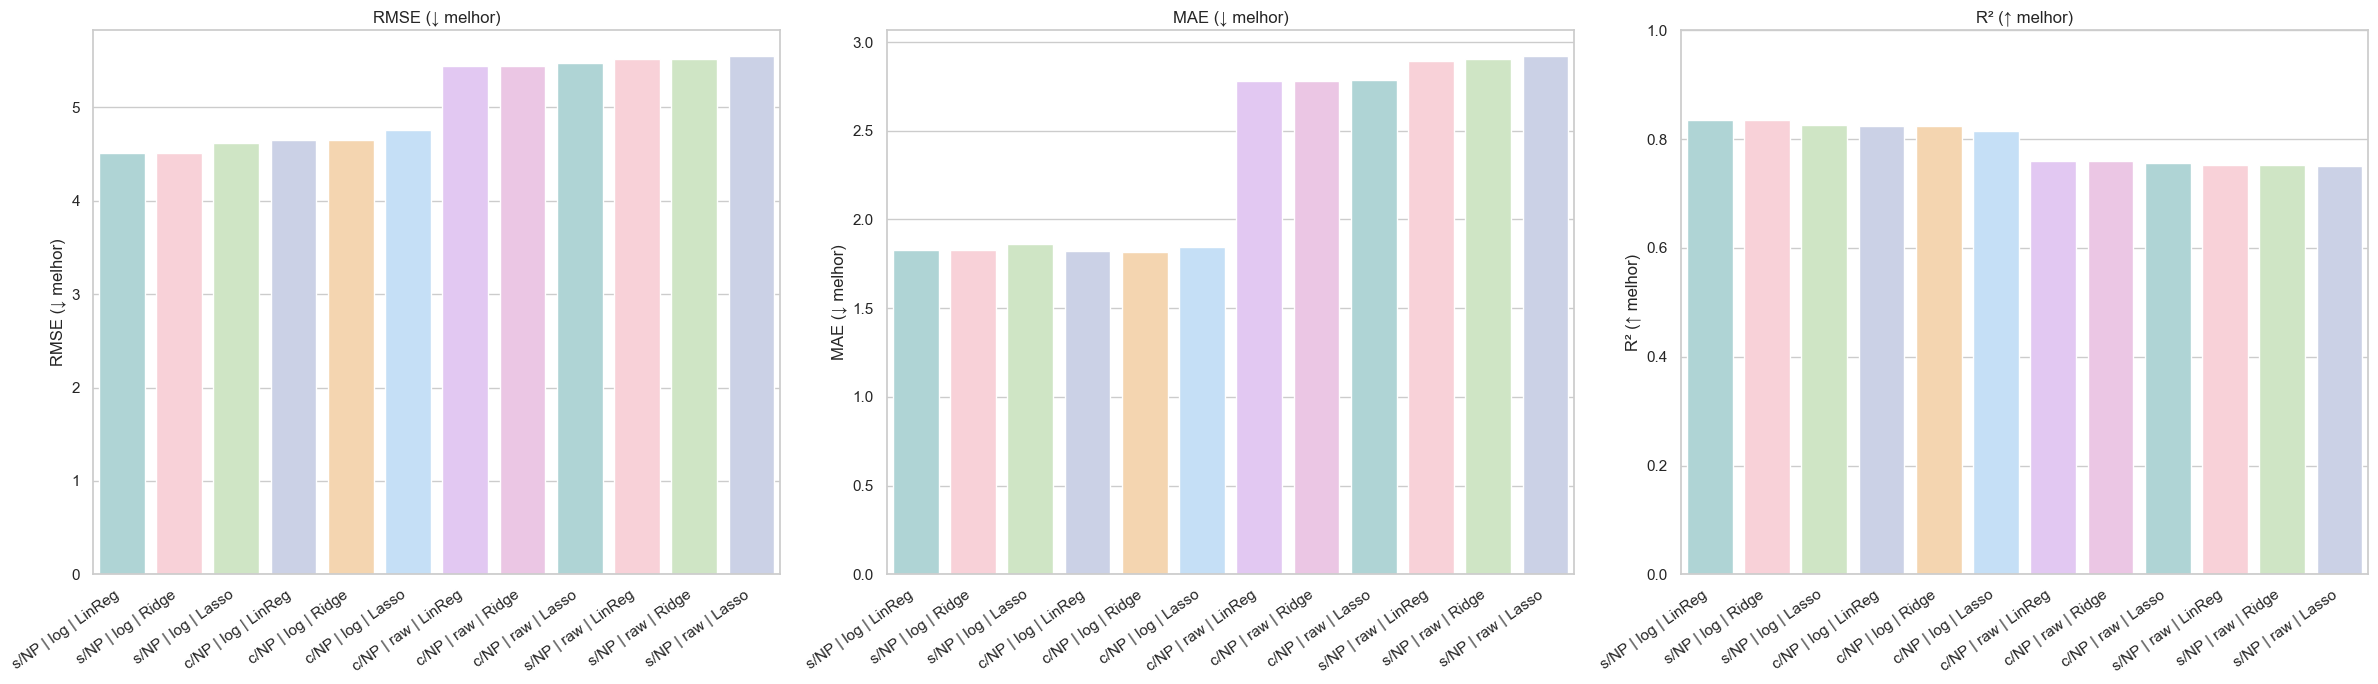

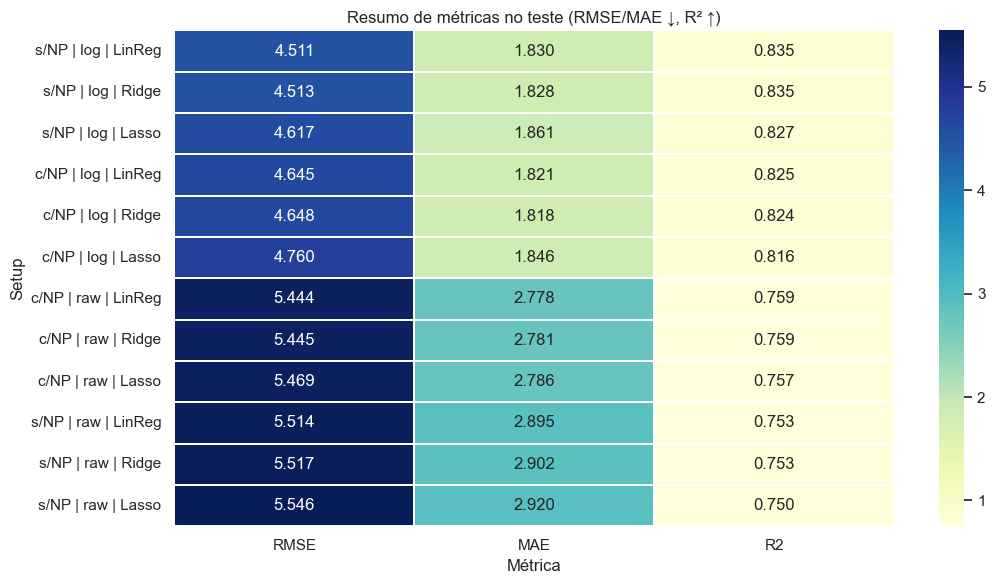

In [49]:
test_metrics = metrics_df.query("split == 'test'").copy()
test_metrics["setup"] = (
    test_metrics["scenario"] + " | " + test_metrics["target_mode"] + " | " + test_metrics["model"]
)

# ordem global pelo RMSE (menor -> melhor)
setup_order = (
    test_metrics.sort_values("RMSE")["setup"].drop_duplicates().tolist()
)
test_metrics["setup"] = pd.Categorical(test_metrics["setup"], categories=setup_order, ordered=True)
test_metrics = test_metrics.sort_values("RMSE")

display(test_metrics)

summary_rmse = test_metrics.pivot_table(
    index=["scenario", "target_mode"],
    columns="model",
    values="RMSE",
)
display(summary_rmse.round(4))

best_by_combo = (
    test_metrics.sort_values("RMSE")
    .groupby(["scenario", "target_mode"], as_index=False)
    .first()[["scenario", "target_mode", "model", "RMSE", "MAE", "R2"]]
)
display(best_by_combo)

# nomes curtos para o eixo x
def short_setup(s):
    s = str(s)
    s = s.replace("sem_new_price", "s/NP")
    s = s.replace("com_new_price", "c/NP")
    s = s.replace("log1p", "log")
    s = s.replace("LinearRegression", "LinReg")
    s = s.replace("RidgeCV", "Ridge")
    s = s.replace("LassoCV", "Lasso")
    return s

label_map = {s: short_setup(s) for s in setup_order}
test_metrics["setup_short"] = test_metrics["setup"].map(label_map)

metric_cfg = [
    ("RMSE", "RMSE (↓ melhor)", True),
    ("MAE", "MAE (↓ melhor)", True),
    ("R2", "R² (↑ melhor)", False),
]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, (metric, title, asc) in zip(axes, metric_cfg):
    mdf = test_metrics.sort_values(metric, ascending=asc).copy()
    sns.barplot(
        data=mdf,
        x="setup_short",
        y=metric,
        palette=sns.color_palette(PASTEL_CYCLE, n_colors=len(mdf)),
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=35)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
    if metric == "R2":
        ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# heatmap melhorado (com direção da métrica)
heatmap_df = test_metrics.set_index("setup_short")[["RMSE", "MAE", "R2"]]
heatmap_df = heatmap_df.loc[[label_map[s] for s in setup_order]]

plt.figure(figsize=(11, max(4, 0.5 * len(heatmap_df))))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar=True,
    linewidths=0.3,
    linecolor="white",
)
plt.title("Resumo de métricas no teste (RMSE/MAE ↓, R² ↑)")
plt.xlabel("Métrica")
plt.ylabel("Setup")
plt.tight_layout()
plt.show()

- neste passo eu organizei os resultados por `setup` e comparei `RMSE`, `MAE` e `R2` de forma direta
- o melhor setup no teste foi `s/NP | log | LinReg` (`RMSE=4.511`, `MAE=1.830`, `R2=0.835`)
- `Ridge` ficou praticamente empatado com `LinReg` no cenário vencedor (`RMSE=4.513`), então o ganho de regularização foi mínimo aqui
- `Lasso` ficou consistentemente um pouco abaixo de `LinReg/Ridge` nos 2 cenários com `log`
- `log1p` na target foi o fator que mais ajudou: todos os setups com `log` superaram os setups com `raw`
- incluir `New_Price` (`c/NP`) não melhorou o teste; no geral ficou pior que `s/NP`
- o heatmap confirma esse padrão: bloco `log` concentra as melhores métricas, bloco `raw` concentra as piores

,scenario,target_mode,model,RMSE_train,RMSE_test,gap_test_minus_train,setup
0,sem_new_price,raw,LinearRegression,5.1930,5.5142,0.3212,sem_new_price | raw | LinearRegression
1,sem_new_price,raw,RidgeCV,5.1941,5.5173,0.3232,sem_new_price | raw | RidgeCV
2,sem_new_price,raw,LassoCV,5.2087,5.5458,0.3370,sem_new_price | raw | LassoCV
3,sem_new_price,log1p,LinearRegression,4.1366,4.5112,0.3745,sem_new_price | log1p | LinearRegression
4,sem_new_price,log1p,RidgeCV,4.1349,4.5129,0.3780,sem_new_price | log1p | RidgeCV
5,sem_new_price,log1p,LassoCV,4.2310,4.6165,0.3855,sem_new_price | log1p | LassoCV
6,com_new_price,raw,LinearRegression,4.9134,5.4436,0.5302,com_new_price | raw | LinearRegression
7,com_new_price,raw,RidgeCV,4.9147,5.4450,0.5303,com_new_price | raw | RidgeCV
8,com_new_price,raw,LassoCV,4.9315,5.4686,0.5371,com_new_price | raw | LassoCV
9,com_new_price,log1p,LinearRegression,3.9881,4.6453,0.6572,com_new_price | log1p | LinearRegression


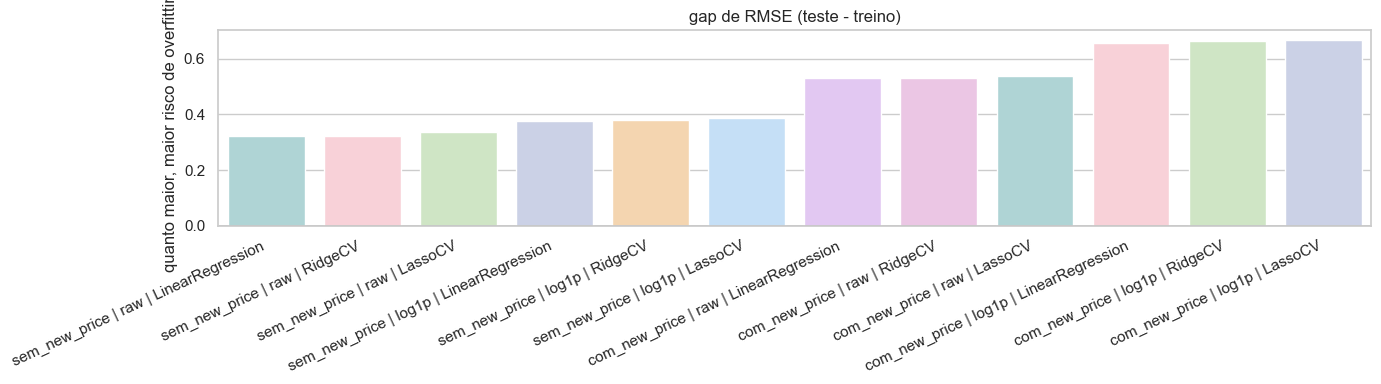

In [50]:
# overfitting vs underfitting (gap de RMSE)
train_rmse = metrics_df.query("split == 'train'")[["scenario", "target_mode", "model", "RMSE"]].rename(columns={"RMSE": "RMSE_train"})
test_rmse = metrics_df.query("split == 'test'")[["scenario", "target_mode", "model", "RMSE"]].rename(columns={"RMSE": "RMSE_test"})

gap_df = train_rmse.merge(test_rmse, on=["scenario", "target_mode", "model"])
gap_df["gap_test_minus_train"] = gap_df["RMSE_test"] - gap_df["RMSE_train"]
gap_df["setup"] = gap_df["scenario"] + " | " + gap_df["target_mode"] + " | " + gap_df["model"]

display(gap_df.sort_values("gap_test_minus_train"))

plt.figure(figsize=(14, 4))
sns.barplot(
    data=gap_df.sort_values("gap_test_minus_train"),
    x="setup",
    y="gap_test_minus_train",
    palette=sns.color_palette(PASTEL_CYCLE, n_colors=len(gap_df)),
)
plt.axhline(0, color="black", linewidth=1)
plt.title("gap de RMSE (teste - treino)")
plt.xlabel("")
plt.ylabel("quanto maior, maior risco de overfitting")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

- neste passo eu medi o gap de generalização (`RMSE_teste - RMSE_treino`) para avaliar risco de overfitting em cada setup
- todos os gaps ficaram positivos, então em todos os casos o erro no teste ficou maior que no treino
- os menores gaps estão no cenário `sem_new_price` (~`0.32` a `0.39`), sugerindo melhor capacidade de generalização
- os maiores gaps estão no cenário `com_new_price`, principalmente com `log1p` (~`0.66`), indicando maior risco de overfitting
- o padrão se mantém entre os modelos `Linear`, `Ridge` e `Lasso` mudam pouco dentro do mesmo cenário/target_mode
- isso reforça a leitura anterior, o principal ganho/perda vem mais da escolha de features e transformação da target do que da troca entre os 3 regressores

## 5) multicolinearidade (numéricas) + leitura da regularização

vif alto indica possível colinearidade. ridge/lasso ajudam a estabilizar os coeficientes nesse cenário

In [ ]:
best_row_for_diag = test_metrics.iloc[0]
best_key_for_diag = (
    best_row_for_diag["scenario"],
    best_row_for_diag["target_mode"],
    best_row_for_diag["model"],
)
best_artifact_for_diag = artifacts[best_key_for_diag]

print(
    "setup selecionado para diagnóstico:",
    f"{best_row_for_diag['scenario']} | {best_row_for_diag['target_mode']} | {best_row_for_diag['model']}"
)

vif_base = best_artifact_for_diag["X_train"][best_artifact_for_diag["numeric_features"]].copy()

# statsmodels exige matriz numérica float; dtypes pandas nullable (Int64, boolean, etc.) quebram o VIF.
vif_base = vif_base.apply(pd.to_numeric, errors="coerce")
vif_base = vif_base.replace([np.inf, -np.inf], np.nan)
vif_base = vif_base.fillna(vif_base.median(numeric_only=True))

# remove colunas constantes, pois VIF não é informativo nesses casos.
constant_cols = [c for c in vif_base.columns if vif_base[c].nunique(dropna=False) <= 1]
if constant_cols:
    print(f"colunas removidas do VIF por serem constantes: {constant_cols}")
    vif_base = vif_base.drop(columns=constant_cols)

if vif_base.shape[1] >= 2:
    vif_array = vif_base.astype(float).to_numpy()
    vif_values = []
    for i, col in enumerate(vif_base.columns):
        vif_values.append({"feature": col, "VIF": variance_inflation_factor(vif_array, i)})
    vif_table = pd.DataFrame(vif_values).sort_values("VIF", ascending=False)
    display(vif_table.round(4))
else:
    print("vif não calculado: menos de 2 features numéricas válidas disponíveis.")

if best_row_for_diag["model"] in ["RidgeCV", "LassoCV"]:
    reg = fitted[best_key_for_diag].named_steps["regressor"]
    alpha = getattr(reg, "alpha_", None)
    print(f"{best_row_for_diag['model']} | alpha selecionado: {alpha}")
else:
    print("LinearRegression não seleciona alpha.")

setup selecionado para diagnóstico: sem_new_price | log1p | LinearRegression


,feature,VIF
4,Engine_num,55.9301
6,Seats,38.6827
5,Power_num,26.9043
2,Mileage_num,12.8399
0,Age,4.6518
1,Kilometers_Driven,4.5460
3,Mileage_is_kmkg,1.0337


LinearRegression não seleciona alpha.


- neste passo eu rodei diagnóstico de multicolinearidade no melhor setup de teste (`sem_new_price | log1p | LinearRegression`)
- o VIF mostrou colinearidade forte entre variáveis técnicas
  - `Engine_num` muito alto (`55.93`)
  - `Power_num` alto (`26.90`)
  - `Mileage_num` alto (`12.84`)
  - `Seats` também elevado (`38.68`)
- `Age` e `Kilometers_Driven` ficaram em faixa intermediária (~`4.6`), enquanto `Mileage_is_kmkg` ficou baixo (`1.03`)

- existe redundância relevante entre features de especificação do carro (motor/potência/consumo), o que pode deixar coeficientes da regressão linear menos estáveis
- isso explica por que faz sentido manter ridge/lasso como comparação mesmo quando o ganho de RMSE é pequeno, regularização ajuda a estabilizar pesos em cenário colinear
- como o melhor setup final foi `LinearRegression`, não há `alpha` para reportar (esperado para esse modelo)

melhor setup por RMSE no teste: sem_new_price | log1p | LinearRegression


,feature,coef,abs_coef
19,cat__Brand_Mini,0.7801,0.7801
15,cat__Brand_Land,0.6468,0.6468
43,cat__Fuel_Type_Petrol,-0.6267,0.6267
25,cat__Brand_Tata,-0.5373,0.5373
40,cat__Fuel_Type_CNG,0.5369,0.5369
42,cat__Fuel_Type_Other,0.4857,0.4857
9,cat__Brand_Chevrolet,-0.4172,0.4172
41,cat__Fuel_Type_Diesel,-0.3960,0.3960
14,cat__Brand_Jaguar,0.3837,0.3837
18,cat__Brand_Mercedes-Benz,0.3680,0.3680


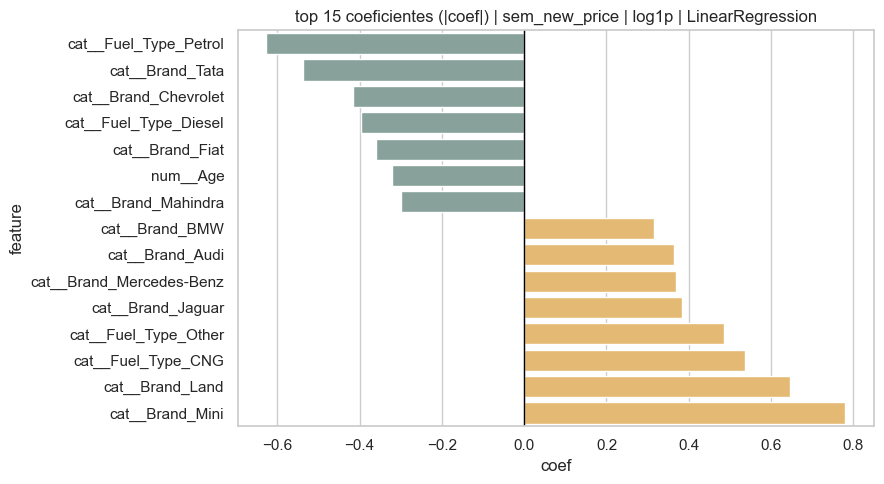

In [51]:
best_row = test_metrics.iloc[0]
best_key = (best_row["scenario"], best_row["target_mode"], best_row["model"])

best_pipe = fitted[best_key]
best_artifact = artifacts[best_key]

X_test_best = best_artifact["X_test"]
y_test_best = best_artifact["y_test"]

best_pred_test_fit = best_pipe.predict(X_test_best)
if best_row["target_mode"] == "log1p":
    best_pred_test = np.expm1(best_pred_test_fit)
else:
    best_pred_test = best_pred_test_fit
best_pred_test = np.clip(best_pred_test, a_min=0, a_max=None)

print(
    "melhor setup por RMSE no teste:",
    f"{best_row['scenario']} | {best_row['target_mode']} | {best_row['model']}"
)

feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()
coefs = best_pipe.named_steps["regressor"].coef_

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs),
}).sort_values("abs_coef", ascending=False)

display(coef_table.head(20).round(4))

top_plot = coef_table.head(15).sort_values("coef")
plt.figure(figsize=(9, 5))
coef_palette = [PASTEL_POS if v >= 0 else PASTEL_NEG for v in top_plot["coef"]]
sns.barplot(data=top_plot, x="coef", y="feature", palette=coef_palette)
plt.axvline(0, color="black", linewidth=1)
plt.title(
    "top 15 coeficientes (|coef|) | "
    f"{best_row['scenario']} | {best_row['target_mode']} | {best_row['model']}"
)
plt.tight_layout()
plt.show()

best_y_test = y_test_best.copy()


- neste passo eu peguei o melhor setup no teste (`sem_new_price | log1p | LinearRegression`) e abri os coeficientes para entender direção e força das variáveis
- os maiores efeitos (|coef|) vieram principalmente de variáveis categóricas de `Brand` e `Fuel_Type`, mostrando que esses grupos carregam bastante sinal de preço
- `num__Age` apareceu com coeficiente negativo (`-0.3204`), coerente com a lógica de negócio: carro mais velho tende a menor preço
- `num__Power_num` apareceu com coeficiente positivo (`+0.2490`), também coerente, mais potência tende a aumentar preço

- sinais positivos/negativos nas dummies devem ser lidos sempre em relação à categoria de referência do one-hot
- como existe colinearidade alta nas numéricas (visto no VIF), magnitude de coeficiente não deve ser tratada como “efeito causal” aqui o foco é interpretação relativa do modelo
- o gráfico dos top coeficientes ajuda a explicar o comportamento do modelo, mas a decisão final continua baseada em performance de teste (RMSE/MAE/R2)

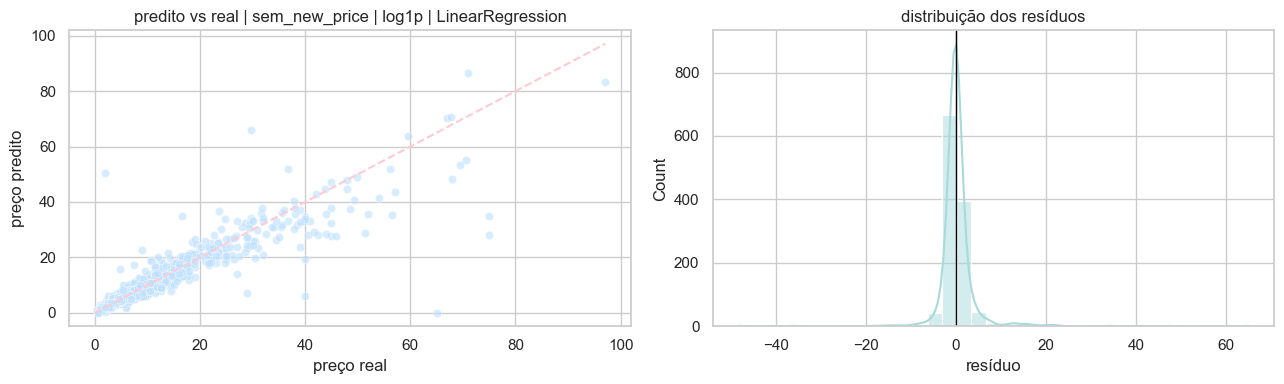

In [ ]:
residuals = best_y_test - best_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(x=best_y_test, y=best_pred_test, alpha=0.6, color=PASTEL_CYCLE[5], ax=axes[0])
mn = min(best_y_test.min(), best_pred_test.min())
mx = max(best_y_test.max(), best_pred_test.max())
axes[0].plot([mn, mx], [mn, mx], color=PASTEL_CYCLE[1], linestyle="--")
axes[0].set_title(
    "predito vs real | "
    f"{best_row['scenario']} | {best_row['target_mode']} | {best_row['model']}"
)
axes[0].set_xlabel("preço real")
axes[0].set_ylabel("preço predito")

sns.histplot(residuals, bins=35, kde=True, ax=axes[1], color=PASTEL_CYCLE[0], edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("distribuição dos resíduos")
axes[1].set_xlabel("resíduo")

plt.tight_layout()
plt.show()

- no gráfico `predito vs real`, a maior parte dos pontos acompanha a diagonal, então o modelo captura bem a tendência geral de preço
- o ajuste é melhor nas faixas baixas/médias; nas faixas mais altas a dispersão aumenta, indicando erro maior para carros muito caros
- há alguns casos extremos longe da diagonal (super/subestimação), que puxam erro absoluto para cima

- na distribuição dos resíduos, os valores estão concentrados perto de `0`, sinal de que o modelo não está sistematicamente enviesado para cima ou para baixo
- a distribuição é aproximadamente centrada, mas com caudas (principalmente para valores positivos), mostrando que ainda existem erros grandes em uma parcela pequena da base